
## Signal Processing Workflow

This notebook demonstrates the process of loading, processing, and visualizing radar signal data. The workflow includes the following steps:

1. **Importing Necessary Libraries**: Import essential libraries and modules required for signal processing and visualization.
2. **Initializing Signal Configuration**: Set up the signal configuration parameters.
3. **Generating Time Array**: Create a time array based on the frame duration and ADC sample rate.
4. **Loading Cycle Data**: Load the cycle data from a specified JSON file.
5. **Processing Antenna Data**: Extract and process the antenna data, including sampling the IF signal.
6. **Performing Range-Doppler FFT**: Compute the Range-Doppler spectrum using FFT.
7. **Visualizing the Spectrum**: Display the Range-Doppler spectrum using a 2D heat map.

Each step is implemented in the subsequent cells of this notebook.


## 1. Importing Necessary Libraries

In [1]:
from scripts import * 


## 2. Initializing Wave Configuration

In [11]:
chirp_config_path = 'data/waveform/chirp_config.yaml'
chirp = load_waveform(chirp_config_path)
chirp.info()


+---------------------+------------------------+
| Parameter           | Value                  |
+=====================+========================+
| numChirpsperFrame   | 255                    |
+---------------------+------------------------+
| numSamplesPerChirps | 255                    |
+---------------------+------------------------+
| frameDuration       | 0.005                  |
+---------------------+------------------------+
| chirpSlope          | 10000000000000.0       |
+---------------------+------------------------+
| startFrequency      | 77000000000.0          |
+---------------------+------------------------+
| Polarization        | HX                     |
+---------------------+------------------------+
| phaseShift          | 0                      |
+---------------------+------------------------+
| chirpDuration       | 1.9607843137254903e-05 |
+---------------------+------------------------+
| adcSampleRate       | 13004999.999999998     |
+-------------------

## 3. load dSpace Ray Tracing .json file

In [12]:
# Load the cycle data from the specified JSON file
cycle_path = 'data/cycles/sensor_0_cycle_0.json'
cycle_data = load_cycle(cycle_path)


## 4. Compute and Sample IF-Signal

In [13]:
ADC_CUBE = cycle2adc(cycle_data, chirp)

## 5. Visualize Range-Doppler Spectrum

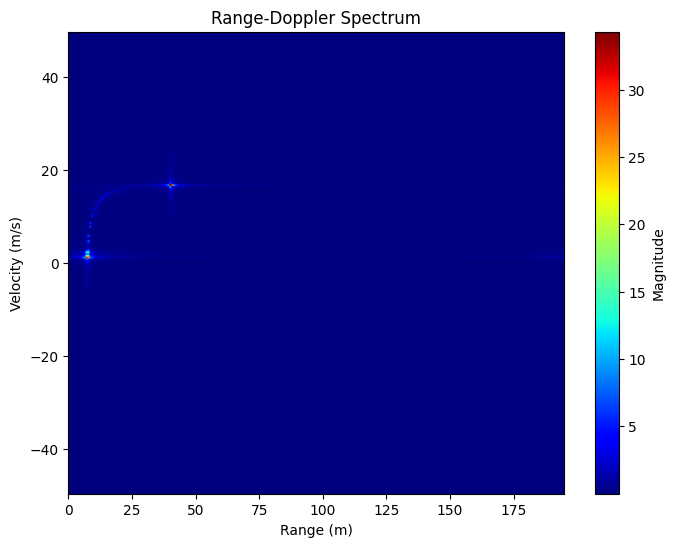

In [14]:
# Perform Range-Doppler FFT on the ADC cube
rd_spectrum = range_doppler_fft(ADC_CUBE, IdxChirps=1, IdxSamples=2)

# Calculate the range axis and velocity axis based on chirp parameters
range_axis = range_bins(
    chirp.numSamplesPerChirps,
    chirp.adcSampleRate,
    chirpSlope=chirp.chirpSlope
)
velocity_axis = velocity_bins(
    chirp.numChirpsperFrame,
    chirp.startFrequency,
    chirp.chirpDuration
)

# Display the 2D heatmap of the Range-Doppler spectrum
show_2D_heat_map(
    rd_spectrum[0][::-1],  # Reverse the range axis for better visualization
    xlabel='Range (m)',
    xaxis=range_axis,
    ylabel='Velocity (m/s)',
    yaxis=velocity_axis,
    title='Range-Doppler Spectrum'
)


## 6. Compare with Reference Range-Doppler Map

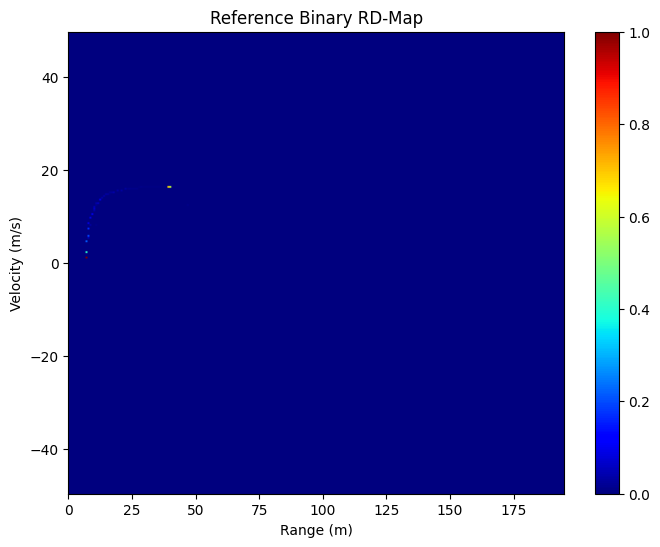

In [15]:
bin_map = cycle2binary(cycle_data, chirp)
bin_map /= np.max(bin_map)

# Plot the heat map
plt.figure(figsize=(8, 6))
plt.imshow(
    bin_map[0][::-1], 
    cmap='jet',
    extent=[range_axis[0], range_axis[-1], velocity_axis[0], velocity_axis[-1]],
    aspect='auto'
)
plt.colorbar()
plt.title('Reference Binary RD-Map')
plt.xlabel('Range (m)')
plt.ylabel('Velocity (m/s)')
plt.show()